# University of London - ML Code - Computer Science Final Project

**BSc Computer Science**

**Subject: CM3070 Computer Science Final Project**

**Student: In Final Project report**

**Student Number: In Final Project report**

## Preparing the data

### Transforming the csv data to a numpy array

In [241]:
import numpy as np

usdYen_raw_data = np.genfromtxt("./data/currency-data/USD-JPY.csv", skip_header=1, delimiter=";", usecols=1)

print("Length: ",len(usdYen_raw_data))
print("Data type: ",usdYen_raw_data.dtype)
print("Raw Data: ",usdYen_raw_data)

Length:  550
Data type:  float64
Raw Data:  [155.21  155.81  155.34  156.15  156.39  154.54  153.4   154.    152.85
 150.62  151.15  147.44  149.49  147.94  147.66  147.38  147.02  146.93
 147.18  147.72  147.36  147.66  148.81  147.4   144.55  144.65  146.07
 144.09  144.85  144.021 142.55  145.581 145.323 144.918 143.623 142.15
 143.49  146.935 149.83  149.275 148.61  148.018 150.545 149.262 152.254
 151.377 155.182 155.92  156.266 157.657 157.273 157.772 156.407 153.683
 149.989 149.743 154.73  154.309 152.608 152.946 152.244 149.485 149.09
 148.679 142.15  143.808 140.764 142.251 146.176 144.367 147.579 146.634
 146.519 153.718 157.44  157.848 160.719 160.835 159.767 157.323 156.752
 157.29  156.943 155.619 155.703 152.949 158.296 154.562 153.24  151.609
 151.303 151.429 149.033 147.03  150.064 150.473 150.181 149.256 148.308
 148.149 148.128 144.904 144.603 140.998 142.401 142.141 144.893 146.772
 149.403 149.562 151.472 149.333 149.599 149.831 149.515 149.274 149.33
 148.36  147.

As the currency data is from newer to older, the order should be inverted.

In [242]:
usdYen_raw_data = np.flip(usdYen_raw_data, axis=0)
print(usdYen_raw_data)

[123.408 122.681 123.861 122.851 122.83  124.05  123.79  123.85  124.197
 124.276 122.002 121.703 119.017 120.567 119.92  120.584 119.898 120.246
 119.442 121.452 120.608 123.136 122.579 122.755 122.741 123.056 120.954
 121.146 120.289 120.203 117.234 116.98  118.71  121.14  116.808 113.236
 112.603 113.975 113.735 113.96  111.543 113.049 111.64  108.079 108.762
 111.793 106.282 107.094 108.633 110.097 110.214 106.532 106.91  104.11
 102.19  102.518 100.5   104.651 106.149 102.047 101.821 101.25  100.21
 101.81  103.975 102.67  102.27  101.05  101.32  102.893 104.146 103.8
 104.694 103.089 106.635 110.874 113.229 113.503 115.274 117.84  117.32
 116.95  117.02  114.467 114.6   115.08  112.584 113.205 112.836 112.134
 114.005 114.77  112.69  111.329 111.383 111.044 108.48  109.08  111.495
 112.7   113.28  111.16  111.31  110.357 110.327 110.67  111.26  112.36
 113.869 112.48  111.153 110.654 110.64  109.05  109.14  109.36  110.247
 107.83  110.731 111.958 112.428 112.545 111.791 113.479 

### Computing the numer of samples for each data split

In [243]:
train_samples_number = int(0.5 * len(usdYen_raw_data))
validation_samples_number = int(0.25 * len(usdYen_raw_data))
test_samples_number = len(usdYen_raw_data) - train_samples_number - validation_samples_number
print("Number of train samples: ", train_samples_number)
print("Number of validation samples: ", validation_samples_number)
print("Number of test samples: ", test_samples_number)

Number of train samples:  275
Number of validation samples:  137
Number of test samples:  138


### Normalizing data

In [244]:
mean = usdYen_raw_data[:train_samples_number].mean(axis=0)
usdYen_raw_data -= mean
std = usdYen_raw_data[:train_samples_number].std(axis=0)
usdYen_raw_data /= std

print(usdYen_raw_data)

[ 2.44666936e+00  2.30352984e+00  2.53586083e+00  2.33700126e+00
  2.33286655e+00  2.57307316e+00  2.52188159e+00  2.53369503e+00
  2.60201609e+00  2.61757045e+00  2.16984108e+00  2.11097078e+00
  1.58212245e+00  1.88730298e+00  1.75991472e+00  1.89065012e+00
  1.75558313e+00  1.82410108e+00  1.66580098e+00  2.06155122e+00
  1.89537550e+00  2.39311510e+00  2.28344700e+00  2.31809975e+00
  2.31534328e+00  2.37736384e+00  1.96349967e+00  2.00130268e+00
  1.83256738e+00  1.81563478e+00  1.23106640e+00  1.18105617e+00
  1.52167702e+00  2.00012133e+00  1.14719097e+00  4.43897520e-01
  3.19265730e-01  5.89399721e-01  5.42145962e-01  5.86446361e-01
  1.10561626e-01  4.07078966e-01  1.29660020e-01 -5.71467636e-01
 -4.36991312e-01  1.59784292e-01 -9.25280159e-01 -7.65404940e-01
 -4.62390208e-01 -1.74142275e-01 -1.51106067e-01 -8.76057493e-01
 -8.01632822e-01 -1.35292668e+00 -1.73095676e+00 -1.66637662e+00
 -2.06370198e+00 -1.24640883e+00 -9.51466618e-01 -1.75911212e+00
 -1.80360941e+00 -1.91603

### Creating timeseries data

In [245]:
from tensorflow import keras

# Parameters
sampling_rate = 1
sequence_length = 4 # Observations will go back 4 weeks
delay = sampling_rate * (sequence_length + 4 - 1) # target is 4 weeks after the end of the sequence
batch_size = 64 # small batch size to start

# train dataset
train_dataset = keras.utils.timeseries_dataset_from_array(
    usdYen_raw_data[:-delay],
    targets=usdYen_raw_data[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    batch_size=batch_size,
    shuffle=True,
    start_index=0,
    end_index=train_samples_number
)

# validation dataset
validation_dataset = keras.utils.timeseries_dataset_from_array(
    usdYen_raw_data[:-delay],
    targets=usdYen_raw_data[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    batch_size=batch_size,
    shuffle=True,
    start_index=train_samples_number,
    end_index=train_samples_number + validation_samples_number
)

# test dataset
test_dataset = keras.utils.timeseries_dataset_from_array(
    usdYen_raw_data[:-delay],
    targets=usdYen_raw_data[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    batch_size=batch_size,
    shuffle=True,
    start_index=train_samples_number + validation_samples_number
)

Checking that it works correctly

In [246]:
for inputs, targets in train_dataset:
    for i in range(inputs.shape[0]):
        print([float(x) for x in inputs[i]], float(targets[i]))

[-1.553952050576598, -0.8557777548643855, -0.02115822877187097, 0.44251928572397226] 1.2479989934957296
[-0.496452292463151, -0.6008043445577541, -0.6460891973535272, -0.45707415959726144] -1.100906631954545
[-0.8221094512640519, -0.9855287026574907, -1.2310513610763083, -0.9319744419598807] -0.38363394180237764
[-0.9099226875549838, -1.100906631954545, -0.9256739407013391, -0.8055706354603779] -0.8075395421036734
[1.887302980573437, 1.7599147207522878, 1.8906501218670395, 1.755583126137039] 1.8953754978109463
[2.52188159170724, 2.5336950315670044, 2.602016092089323, 2.6175704545713483] 1.887302980573437
[0.21018830181522888, 0.3121776659378786, 0.5273791620499625, 0.5370268046021065] 0.4289338298852401
[-0.22178981572357348, -0.06132392429507643, -0.10188340114694266, 0.2655145784918012] -0.03631880992523786
[-0.06723064422496, -0.3802868005087779, -0.3625666407191272, -0.31925069456664956] 0.19227125136124779
[2.6175704545713483, 2.169841083886191, 2.110970775251688, 1.58212245086279

Inspecting the output

In [247]:
for samples, targets in train_dataset:
    print("Samples: ", samples)
    print("Sample shape: ", samples.shape)
    print("Targets: ", targets)
    print("Targets shape: ", targets.shape)
    break

Samples:  tf.Tensor(
[[-5.71467636e-01 -4.36991312e-01  1.59784292e-01 -9.25280159e-01]
 [-1.37950692e+00 -1.63644924e+00 -1.71520550e+00 -1.95541212e+00]
 [ 1.23106640e+00  1.18105617e+00  1.52167702e+00  2.00012133e+00]
 [-2.10960829e-01 -3.17903246e-02  1.47380180e-01  2.04478473e-01]
 [-2.14701752e-01 -2.03085203e-01 -3.31064134e-01 -5.33861519e-01]
 [-8.79041640e-02 -7.11684575e-02  1.76519998e-01  2.33390614e-02]
 [-4.36991312e-01  1.59784292e-01 -9.25280159e-01 -7.65404940e-01]
 [ 5.48415677e-02  2.71421298e-01  5.68529311e-01  2.95048178e-01]
 [ 4.40125811e-02 -3.63188099e-02 -9.67642439e-02  4.61783784e-02]
 [-4.62390208e-01 -1.74142275e-01 -1.51106067e-01 -8.76057493e-01]
 [ 4.91741952e-01  5.26985381e-01  5.91565519e-01  4.97845562e-01]
 [-5.67332932e-01 -6.82513970e-01 -6.02773251e-01 -8.07539542e-01]
 [-1.66637662e+00 -2.06370198e+00 -1.24640883e+00 -9.51466618e-01]
 [ 3.94477964e-01 -7.96655426e-03 -7.21529108e-02 -4.85426415e-01]
 [-1.74142275e-01 -1.51106067e-01 -8.7605

## Simple LSTM Model

In [248]:
from keras import models
from keras import layers

def build_lstm_model():
    model = models.Sequential()
    model.add(layers.LSTM(16, input_shape=(sequence_length, 1)))
    model.add(layers.Dense(1))
    model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
    return model

model = build_lstm_model()
callbacks = [keras.callbacks.ModelCheckpoint("usd_jpy_lstm.keras", save_best_only=True)]
history = model.fit(train_dataset, epochs=20, validation_data=validation_dataset, callbacks=callbacks)
model = keras.models.load_model("usd_jpy_lstm.keras")
model.summary()
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")
    

Epoch 1/20


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 1.0178 - mae: 0.7555 - val_loss: 12.2104 - val_mae: 2.6401
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9154 - mae: 0.7165 - val_loss: 11.5277 - val_mae: 2.5576
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8437 - mae: 0.6877 - val_loss: 10.9221 - val_mae: 2.4831
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7804 - mae: 0.6621 - val_loss: 10.4487 - val_mae: 2.4219
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7267 - mae: 0.6390 - val_loss: 9.9019 - val_mae: 2.3528
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6761 - mae: 0.6166 - val_loss: 9.5289 - val_mae: 2.3019
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6334 - mae: 0.5968 - val_loss: 9.0481 - val_mae: 2.2369
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5885 - mae: 0.5737 - val_loss: 8.5865 - val_mae: 2.1758
Epoch 9/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5508 - mae: 0.5559 - val_loss: 8.188

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_32 (LSTM)                  │ (None, 16)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340 (9.14 KB)

 Trainable params: 1,169 (4.57 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,171 (4.58 KB)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 34.0677 - mae: 5.7586  
Test MAE: 5.76


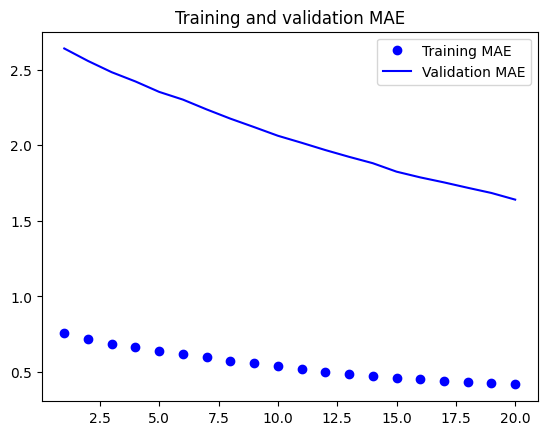

In [249]:
import matplotlib.pyplot as plt
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()